# CNN-Transformer-BiGRU 训练脚本 v7（彻底回退版）

修复策略：
- 模型完全复刻原成功架构（the_other_model.ipynb）
- 仅添加输出前 Dropout 防止最终层过拟合
- 训练使用 ReduceLROnPlateau（比 StepLR 更平滑，根据验证 loss 自动调整）
- 适度 weight_decay（1e-4）
- 早停耐心 15（平衡收敛和防止过拟合）

In [12]:
import os
import math
import random
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import import_ipynb

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.5.1
CUDA available: True


---
## 第 1 步：配置参数

In [13]:
@dataclass
class TrainConfig:
    batch_size: int = 64
    seq_len: int = 168
    pred_len: int = 24
    input_dim: int = 53
    lr: float = 1e-3
    weight_decay: float = 1e-4        # 原模型配置
    epochs: int = 80                  # 足够收敛
    max_grad_norm: float = 1.0
    # ReduceLROnPlateau 参数（根据验证 loss 自动调整，更平滑）
    lr_patience: int = 8              # 验证 loss 不改善 8 轮后降低学习率
    lr_factor: float = 0.5            # 衰减因子
    lr_min: float = 1e-6              # 最小学习率
    # 早停
    early_stop_patience: int = 15     # 平衡收敛和防止过拟合
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    checkpoint_path: str = "checkpoints/v7_model.pt"
    data_dir: str = "processed_data"

tconfig = TrainConfig()
print(tconfig)

TrainConfig(batch_size=64, seq_len=168, pred_len=24, input_dim=53, lr=0.001, weight_decay=0.0001, epochs=80, max_grad_norm=1.0, lr_patience=8, lr_factor=0.5, lr_min=1e-06, early_stop_patience=15, device='cuda', checkpoint_path='checkpoints/v7_model.pt', data_dir='processed_data')


---
## 第 2 步：加载数据

In [14]:
def load_processed_data(data_dir='processed_data'):
    train = np.load(os.path.join(data_dir, 'train.npz'))
    val = np.load(os.path.join(data_dir, 'val.npz'))
    test = np.load(os.path.join(data_dir, 'test.npz'))
    scaler = np.load(os.path.join(data_dir, 'scaler.npz'), allow_pickle=True)
    return {
        'X_train': train['X'], 'y_train': train['y'],
        'X_val': val['X'], 'y_val': val['y'],
        'X_test': test['X'], 'y_test': test['y'],
        'scaler': scaler
    }

data = load_processed_data(tconfig.data_dir)
print(f"训练集: X={data['X_train'].shape}, y={data['y_train'].shape}")
print(f"验证集: X={data['X_val'].shape}, y={data['y_val'].shape}")
print(f"测试集: X={data['X_test'].shape}, y={data['y_test'].shape}")

训练集: X=(17925, 168, 53), y=(17925, 24)
验证集: X=(3841, 168, 53), y=(3841, 24)
测试集: X=(3842, 168, 53), y=(3842, 24)


---
## 第 3 步：Dataset 和 DataLoader

In [15]:
class LoadForecastDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = LoadForecastDataset(data['X_train'], data['y_train'])
val_dataset = LoadForecastDataset(data['X_val'], data['y_val'])
test_dataset = LoadForecastDataset(data['X_test'], data['y_test'])

train_loader = DataLoader(train_dataset, batch_size=tconfig.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=tconfig.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=tconfig.batch_size, shuffle=False)

print(f"DataLoader: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}")

DataLoader: train=281, val=61, test=61


---
## 第 4 步：训练工具

In [16]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=0, checkpoint_path="best_model.pt"):
        self.patience = patience
        self.min_delta = min_delta
        self.checkpoint_path = checkpoint_path
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False
        dir_name = os.path.dirname(checkpoint_path)
        if dir_name:
            os.makedirs(dir_name, exist_ok=True)
    
    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'best_loss': val_loss,
            }, self.checkpoint_path)
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
            return False

def train_epoch(model, train_loader, criterion, optimizer, device, max_grad_norm):
    model.train()
    total_loss = 0.0
    total_samples = 0
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()
        pred, _ = model(batch_x)
        loss = criterion(pred, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
        optimizer.step()
        total_loss += loss.item() * batch_x.size(0)
        total_samples += batch_x.size(0)
    return total_loss / total_samples

def val_epoch(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    all_preds = []
    all_trues = []
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            pred, _ = model(batch_x)
            loss = criterion(pred, batch_y)
            total_loss += loss.item() * batch_x.size(0)
            total_samples += batch_x.size(0)
            all_preds.append(pred.cpu().numpy())
            all_trues.append(batch_y.cpu().numpy())
    avg_loss = total_loss / total_samples
    all_preds = np.concatenate(all_preds, axis=0)
    all_trues = np.concatenate(all_trues, axis=0)
    return avg_loss, all_preds, all_trues

print("训练工具定义完成")

训练工具定义完成


---
## 第 5 步：加载 v7 模型

In [ ]:
from model_v7 import Improved_CNN_Transformer_BiGRU, ModelConfig

mconfig = ModelConfig(
    input_dim=tconfig.input_dim,
    cnn_out_dim=32,
    d_model=128,
    nhead=4,
    num_encoder_layers=2,       # 完全复刻原模型
    dim_feedforward=256,
    dropout=0.1,                # 完全复刻原模型
    output_len=tconfig.pred_len
)
model = Improved_CNN_Transformer_BiGRU(mconfig)

total_params = sum(p.numel() for p in model.parameters())
print(f"模型创建完成")
print(f"  总参数量: {total_params:,}")
print(f"  模型大小: {total_params * 4 / 1024 / 1024:.2f} MB")

dummy_input = torch.randn(2, tconfig.seq_len, tconfig.input_dim)
with torch.no_grad():
    dummy_output, _ = model(dummy_input)
print(f"\n前向传播测试: {dummy_input.shape} -> {dummy_output.shape}")
assert dummy_output.shape == (2, tconfig.pred_len)
print("  ✓ 维度正确")

模型创建完成
  总参数量: 359,896
  模型大小: 1.37 MB

前向传播测试: torch.Size([2, 168, 53]) -> torch.Size([2, 24])
  ✓ 维度正确


---
## 第 6 步：主训练循环（ReduceLROnPlateau）

In [18]:
def train(model, train_loader, val_loader, config: TrainConfig):
    model = model.to(config.device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=config.lr, weight_decay=config.weight_decay
    )
    
    # ReduceLROnPlateau：根据验证 loss 自动调整学习率
    # 优点：只在验证 loss 停滞时才降低学习率，比 StepLR 更智能、更平滑
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=config.lr_factor, 
        patience=config.lr_patience, min_lr=config.lr_min, verbose=True
    )
    
    early_stopping = EarlyStopping(
        patience=config.early_stop_patience,
        checkpoint_path=config.checkpoint_path
    )
    history = {'train_loss': [], 'val_loss': [], 'lr': []}
    
    print("\n" + "="*70)
    print("开始训练 v7 模型（彻底回退版）...")
    print(f"  d_model={mconfig.d_model}, nhead={mconfig.nhead}, layers={mconfig.num_encoder_layers}")
    print(f"  Dropout={mconfig.dropout}, weight_decay={config.weight_decay}")
    print(f"  ReduceLROnPlateau: patience={config.lr_patience}, factor={config.lr_factor}")
    print(f"  早停耐心: {config.early_stop_patience}")
    print("="*70 + "\n")
    
    for epoch in range(1, config.epochs + 1):
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, 
            config.device, config.max_grad_norm
        )
        val_loss, _, _ = val_epoch(model, val_loader, criterion, config.device)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        
        # ReduceLROnPlateau 根据验证 loss 调整
        scheduler.step(val_loss)
        is_best = early_stopping(val_loss, model)
        status = "[最佳]" if is_best else ""
        
        if epoch % 5 == 0 or is_best:
            print(f"Epoch {epoch:3d}/{config.epochs} "
                  f"| Train: {train_loss:.6f} | Val: {val_loss:.6f} "
                  f"| LR: {optimizer.param_groups[0]['lr']:.2e} {status}")
        
        if early_stopping.early_stop:
            print(f"\n早停触发（第{epoch}轮），加载最佳模型...")
            checkpoint = torch.load(config.checkpoint_path, map_location=config.device, weights_only=True)
            model.load_state_dict(checkpoint['model_state_dict'])
            print(f"已加载最佳模型（验证 loss: {checkpoint['best_loss']:.6f}）")
            break
    
    return model, history

trained_model, history = train(model, train_loader, val_loader, tconfig)
print("\n训练完成！")


开始训练 v7 模型（彻底回退版）...
  d_model=128, nhead=4, layers=2
  Dropout=0.1, weight_decay=0.0001
  ReduceLROnPlateau: patience=8, factor=0.5
  早停耐心: 15



c:\ProgramData\miniconda3\envs\loadforecast\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch   1/80 | Train: 0.029188 | Val: 0.005854 | LR: 1.00e-03 [最佳]
Epoch   2/80 | Train: 0.007509 | Val: 0.005606 | LR: 1.00e-03 [最佳]
Epoch   3/80 | Train: 0.005542 | Val: 0.004980 | LR: 1.00e-03 [最佳]
Epoch   4/80 | Train: 0.004663 | Val: 0.003752 | LR: 1.00e-03 [最佳]
Epoch   5/80 | Train: 0.004191 | Val: 0.005376 | LR: 1.00e-03 
Epoch   7/80 | Train: 0.003509 | Val: 0.002878 | LR: 1.00e-03 [最佳]
Epoch  10/80 | Train: 0.003027 | Val: 0.003299 | LR: 1.00e-03 
Epoch  13/80 | Train: 0.002639 | Val: 0.002414 | LR: 1.00e-03 [最佳]
Epoch  15/80 | Train: 0.002486 | Val: 0.003170 | LR: 1.00e-03 
Epoch  17/80 | Train: 0.002415 | Val: 0.002412 | LR: 1.00e-03 [最佳]
Epoch  20/80 | Train: 0.002312 | Val: 0.002651 | LR: 1.00e-03 
Epoch  23/80 | Train: 0.002281 | Val: 0.002152 | LR: 1.00e-03 [最佳]
Epoch  25/80 | Train: 0.002243 | Val: 0.002787 | LR: 1.00e-03 
Epoch  30/80 | Train: 0.002153 | Val: 0.003158 | LR: 1.00e-03 
Epoch  35/80 | Train: 0.001917 | Val: 0.003473 | LR: 5.00e-04 

早停触发（第38轮），加载最佳模型...
已

---
## 第 7 步：训练可视化

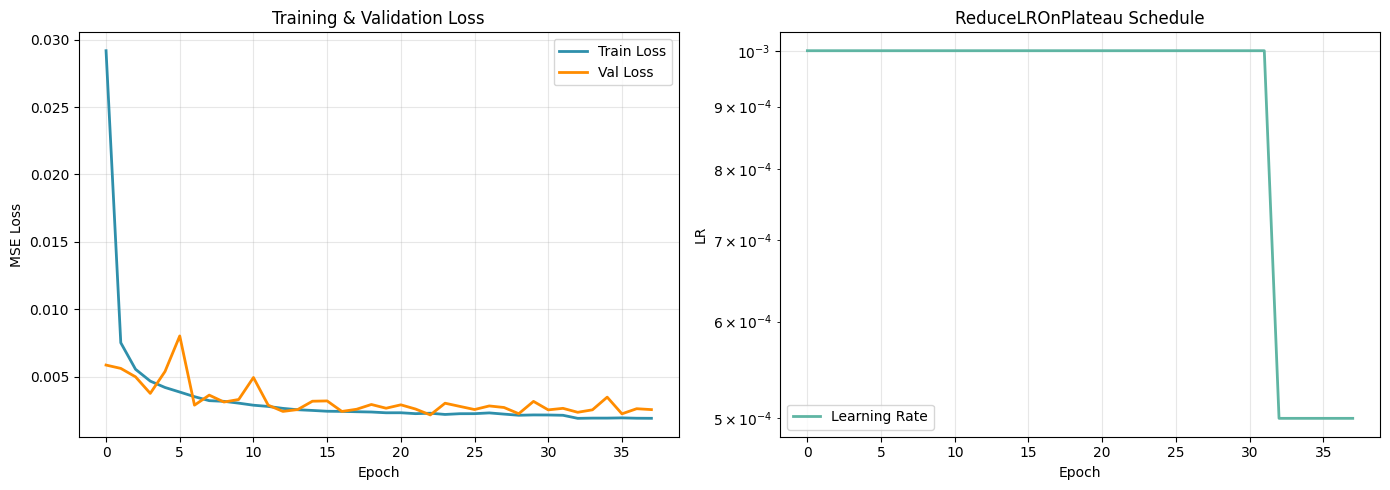

✓ 训练曲线已保存


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='#2E8FAB', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', color='#FF8C00', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['lr'], label='Learning Rate', color='#5FB5A3', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('LR')
axes[1].set_title('ReduceLROnPlateau Schedule')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('processed_data/visualization/v7_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ 训练曲线已保存")

---
## 第 8 步：反归一化器

In [20]:
class MinMaxScalerInverse:
    def __init__(self, scaler_npz):
        self.data_min = scaler_npz['min']
        self.data_max = scaler_npz['max']
        self.target_idx = int(scaler_npz['target_idx'])
    
    def inverse_transform_target(self, y_normalized):
        target_min = self.data_min[self.target_idx]
        target_max = self.data_max[self.target_idx]
        return y_normalized * (target_max - target_min) + target_min

target_scaler = MinMaxScalerInverse(data['scaler'])
print(f"反归一化器 OK: 范围 [{target_scaler.data_min[target_scaler.target_idx]:.0f}, "
      f"{target_scaler.data_max[target_scaler.target_idx]:.0f}]")

反归一化器 OK: 范围 [1811, 4980]


---
## 第 9 步：测试集评估

In [21]:
def calculate_metrics(y_true, y_pred):
    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)
    rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100
    smape = np.mean(2 * np.abs(y_true_flat - y_pred_flat) / 
                    (np.abs(y_true_flat) + np.abs(y_pred_flat) + 1e-8)) * 100
    ss_res = np.sum((y_true_flat - y_pred_flat) ** 2)
    ss_tot = np.sum((y_true_flat - np.mean(y_true_flat)) ** 2)
    r2 = 1 - (ss_res / (ss_tot + 1e-8))
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'SMAPE': smape, 'R2': r2}

def evaluate_test_set(model, test_loader, target_scaler, device):
    model.eval()
    all_preds = []
    all_trues = []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            pred, _ = model(batch_x)
            all_preds.append(pred.cpu().numpy())
            all_trues.append(batch_y.cpu().numpy())
    test_preds = np.concatenate(all_preds, axis=0)
    test_trues = np.concatenate(all_trues, axis=0)
    test_preds_inv = target_scaler.inverse_transform_target(test_preds)
    test_trues_inv = target_scaler.inverse_transform_target(test_trues)
    metrics = calculate_metrics(test_trues_inv, test_preds_inv)
    return metrics, test_preds_inv, test_trues_inv

print("正在评估测试集...")
test_metrics, test_preds, test_trues = evaluate_test_set(trained_model, test_loader, target_scaler, tconfig.device)

print("\n测试集评估指标:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

正在评估测试集...

测试集评估指标:
  RMSE: 164.3262
  MAE: 123.8374
  MAPE: 3.6290
  SMAPE: 3.6754
  R2: 0.9255


---
## 第 10 步：保存结果

In [22]:
import json

training_info = {
    'model_config': {
        'input_dim': mconfig.input_dim,
        'cnn_out_dim': mconfig.cnn_out_dim,
        'd_model': mconfig.d_model,
        'nhead': mconfig.nhead,
        'num_encoder_layers': mconfig.num_encoder_layers,
        'dim_feedforward': mconfig.dim_feedforward,
        'dropout': mconfig.dropout,
    },
    'train_config': {
        'batch_size': tconfig.batch_size,
        'lr': tconfig.lr,
        'weight_decay': tconfig.weight_decay,
        'scheduler': 'ReduceLROnPlateau',
        'lr_patience': tconfig.lr_patience,
        'lr_factor': tconfig.lr_factor,
        'epochs': len(history['train_loss']),
    },
    'test_metrics': test_metrics,
    'history': {
        'train_loss': [float(x) for x in history['train_loss']],
        'val_loss': [float(x) for x in history['val_loss']],
        'lr': [float(x) for x in history['lr']],
    }
}

info_path = 'checkpoints/v7_training_info.json'
with open(info_path, 'w', encoding='utf-8') as f:
    json.dump(training_info, f, indent=2, ensure_ascii=False)

print(f"✓ 训练信息已保存: {info_path}")
print(f"\n训练摘要:")
print(f"  总训练轮数: {len(history['train_loss'])}")
print(f"  最佳验证 loss: {min(history['val_loss']):.6f}")
print(f"  测试集 MAPE: {test_metrics['MAPE']:.2f}%")
print(f"  测试集 R2: {test_metrics['R2']:.4f}")

✓ 训练信息已保存: checkpoints/v7_training_info.json

训练摘要:
  总训练轮数: 38
  最佳验证 loss: 0.002152
  测试集 MAPE: 3.63%
  测试集 R2: 0.9255
